<a href="https://colab.research.google.com/github/priyanshu-p-dey/Determination-of-hubbles-constant/blob/main/hubbles_law.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants
from scipy.optimize import curve_fit


In [7]:
column_names = [
    'Supernova_Name',
    'Redshift_z',
    'Distance_Modulus_mu',
    'Modulus_Error',
    'Prob_Low_Mass_Galaxy'
]

df = pd.read_csv(
    'dataset/data.txt',
    sep=r'\s+',
    comment='#',
    names=column_names,
)

In [8]:
c = constants.c/1000 #speed of light in km/s

redshift=df['Redshift_z']

redshift_less_than_point_1 = df.loc[redshift < 0.1, 'Redshift_z']
redshift_greater_than_point_1 = df.loc[redshift > 0.1, 'Redshift_z']

d_mod=df.loc[redshift < 0.1, 'Distance_Modulus_mu']

v=(redshift_less_than_point_1 * c).to_numpy()
v_sorted=np.sort(v)

d=(10**((d_mod-25)/5)).to_numpy()
d_sorted=np.sort(d)

In [9]:
#linear fitting
def hubbles_law(H0,d):
    return H0*d;

popt,pcov=curve_fit(hubbles_law, d_sorted, v_sorted)
calc_H0=popt[0]

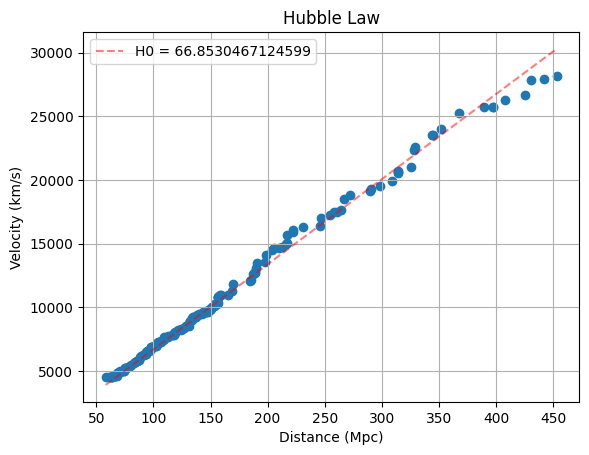

In [10]:
# Plotting graph

plt.style.use('default')

plt.grid(True)
plt.plot(d_sorted, hubbles_law(calc_H0,d_sorted), color='red', linestyle='dashed', alpha=0.5)
plt.scatter(d_sorted,v_sorted,marker='o')
plt.legend(['H0 = '+str(calc_H0)])
plt.title('Hubble Law')
plt.xlabel('Distance (Mpc)')
plt.ylabel('Velocity (km/s)')
plt.show()